<h1><center>ML Project (ECommerce Analysis)</center></h1>
<center>The objective of this project is to demonstrate the analysis of ecommerce data. The project aims to show how ecommerce data can be visualised and time-series forecasting can be applied to predict users growth.</center>
<br>

<h3><center>By: Gee Jun Hui Leonidas Yunani</center></h3>
<center>Email: leonidas.gee@studio.unibo.it</center>
<center>Academic Year: 2021 / 2022</center>

In [1]:
!pip install plotly==5.1.0
!pip install pmdarima
!pip install geopy

In [2]:
# Import the necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.preprocessing import LabelEncoder
import plotly.express as px
from pmdarima.arima import auto_arima
from datetime import timedelta
from geopy.geocoders import ArcGIS
geolocator = ArcGIS()
from tqdm import tqdm
tqdm.pandas()

# Set the mode to online or offline
mode = 'offline' # online # offline

C:\Users\Mordecai\Anaconda3\lib\site-packages\tqdm\std.py:697: FutureWarning: The Panel class is removed from pandas. Accessing it from the top-level namespace will also be removed in the next version
  from pandas import Panel


## Data Import

In [3]:
# Load the datasets
customers = pd.read_csv('dataset/olist_customers_dataset.csv')
orders = pd.read_csv('dataset/olist_orders_dataset.csv')
items = pd.read_csv('dataset/olist_order_items_dataset.csv')
products = pd.read_csv('dataset/olist_products_dataset.csv')
categories = pd.read_csv('dataset/product_category_name_translation.csv')
payments = pd.read_csv('dataset/olist_order_payments_dataset.csv')

In [4]:
# Preview the customers dataset
print('Numbers of rows & columns: {}'.format(customers.shape))
print(list(customers.columns))

Numbers of rows & columns: (99441, 5)
['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']


In [5]:
# Preview the orders dataset
print('Numbers of rows & columns: {}'.format(orders.shape))
print(list(orders.columns))

Numbers of rows & columns: (99441, 8)
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']


In [6]:
# Preview the items dataset
print('Numbers of rows & columns: {}'.format(items.shape))
print(list(items.columns))

Numbers of rows & columns: (112650, 7)
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']


In [7]:
# Preview the products dataset
print('Numbers of rows & columns: {}'.format(products.shape))
print(list(products.columns))

Numbers of rows & columns: (32951, 9)
['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']


In [8]:
# Preview the categories dataset
print('Numbers of rows & columns: {}'.format(categories.shape))
print(list(categories.columns))

Numbers of rows & columns: (71, 2)
['product_category_name', 'product_category_name_english']


In [9]:
# Preview the payments dataset
print('Numbers of rows & columns: {}'.format(payments.shape))
print(list(payments.columns))

Numbers of rows & columns: (103886, 5)
['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']


## Data Preparation

In [10]:
# Inner join all the tables
data = customers.merge(orders, on='customer_id')
data = data.merge(items, on='order_id')
data = data.merge(products, on='product_id')
data = data.merge(categories, on='product_category_name')
data = data.merge(payments, on='order_id')
print('Number of rows & columns: {}'.format(data.shape))

Number of rows & columns: (115878, 31)


In [11]:
# Rearrange the columns
data = data[['order_purchase_timestamp', 'customer_unique_id', 'customer_state',    
             'product_category_name_english', 'payment_type', 'price', 'order_item_id']]

# Rename the columns
data.columns = ['Date', 'Customer', 'State', 'Product', 'Payment', 'Price', 'Orders']

In [12]:
# Replace the state codes with state names
states = {'AC': 'Acre', 'AL': 'Alagoas', 'AP': 'Amapá', 'AM': 'Amazonas', 'BA': 'Bahia', 
          'CE': 'Ceará', 'DF': 'Distrito Federal', 'ES': 'Espírito Santo', 'GO': 'Goiás', 'MA': 'Maranhão', 
          'MT': 'Mato Grosso', 'MS': 'Mato Grosso do Sul', 'MG': 'Minas Gerais', 'PA': 'Pará', 'PB': 'Paraíba', 
          'PR': 'Paraná', 'PE': 'Pernambuco', 'PI': 'Piauí', 'RJ': 'Rio de Janeiro', 'RN': 'Rio Grande do Norte', 
          'RS': 'Rio Grande do Sul', 'RO': 'Rondônia', 'RR': 'Roraima', 'SC': 'Santa Catarina', 'SP': 'São Paulo', 
          'SE': 'Sergipe', 'TO': 'Tocantins'}

data['State'] = data['State'].replace(states)

In [13]:
# Change the customer id into unique integer keys
le = LabelEncoder()
data['Customer'] = le.fit_transform(data['Customer'])

In [14]:
# Replace underscores with spaces
data['Product'] = data['Product'].str.replace('_', ' ')
data['Payment'] = data['Payment'].str.replace('_', ' ')

# Change strings to camel case
data['Product'] = data['Product'].str.title()
data['Payment'] = data['Payment'].str.title()

In [15]:
# Keep only the date part from date
data['Date'] = pd.to_datetime(data['Date']).dt.date

# Add a sales column
data['Sales'] = data['Orders'] * data['Price']

In [16]:
# Sort transactions by date
data = data.sort_values(by='Date', ignore_index=True)

# Preview the dataset
print('Number of rows & columns: {}'.format(data.shape))
data.head(3)

Number of rows & columns: (115878, 8)


,Date,Customer,State,Product,Payment,Price,Orders,Sales
0,2016-09-04,67670,Roraima,Furniture Decor,Credit Card,32.90,2,65.80
1,2016-09-04,67670,Roraima,Furniture Decor,Credit Card,39.99,1,39.99
2,2016-09-05,26676,Rio Grande do Sul,Telephony,Credit Card,59.50,1,59.50


## Data Visualisation

### Customer by Payment

Customers can be divided by payment into 4 categories. It can be seen that most customers pay using credit cards and a local payment system called Boletao in Brazil.

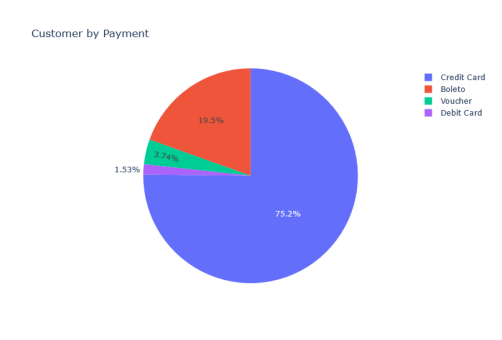

In [17]:
# Plot the customer by payment graph
if mode == 'online':
    # Get the customer by payment
    group_df = data[['Payment', 'Customer']].groupby('Payment').agg('nunique')
    customer_by_payment = pd.DataFrame()
    customer_by_payment['Payment'] = group_df.index
    customer_by_payment['Customer'] = group_df.values

    fig = px.pie(customer_by_payment, values='Customer', names='Payment', title='Customer by Payment')
    fig.show()
    
elif mode == 'offline':
    plt.figure(figsize=(14, 6))
    image = plt.imread('images/customer_by_payment.png')
    plt.axis('off')
    plt.imshow(image)

### Orders by Product

Using an icicle chart, the products with the most orders can be shown. Based on the chart, the top 5 products include Bed Bath Table, Furniture Decor, Health Beauty, Sports Leisure and Computers Accessories.

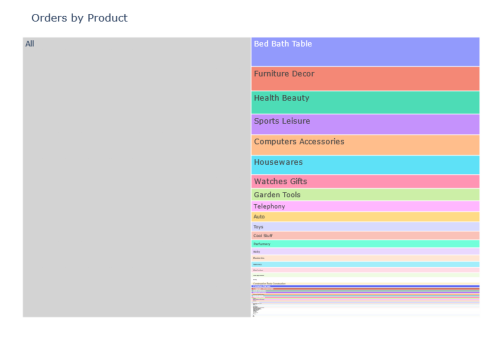

In [18]:
# Plot the orders by product graph
if mode == 'online':
    # Get the orders by product
    group_df = data[['Product', 'Orders']].groupby('Product').agg('sum')
    orders_by_product = pd.DataFrame()
    orders_by_product['Product'] = group_df.index
    orders_by_product['Orders'] = group_df.values

    fig = px.icicle(orders_by_product, values='Orders', path=[px.Constant('All'), 'Product'], title='Orders by Product')
    fig.update_traces(root_color="lightgrey")
    fig.update_layout(margin = dict(t=50, l=25, r=25, b=25))
    fig.show()
    
elif mode == 'offline':
    plt.figure(figsize=(14, 6))
    image = plt.imread('images/orders_by_product.png')
    plt.axis('off')
    plt.imshow(image)

### Sales by State

Based on a bubble map, the location and size of sales from customers throughout the states in Brazil can be visualised. São Paulo, Rio de Janeiro and Minas Gerais are the states with the largest sales from customers.

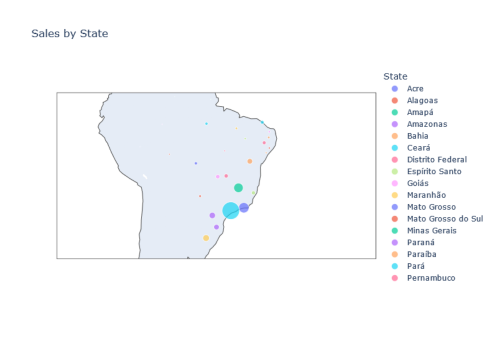

In [19]:
# Plot the sales by state graph
if mode == 'online':
    # Get the sales by state
    group_df = data[['State', 'Sales']].groupby('State').agg('sum')
    sales_by_state = pd.DataFrame()
    sales_by_state['State'] = group_df.index
    sales_by_state['Sales'] = group_df.values

    def get_location(args):
        location = geolocator.geocode(args[0] + ', Brazil')
        return pd.Series([args[0], location.longitude, location.latitude, args[1]])

    sales_by_state[['State', 'Longitude', 'Latitude', 'Sales']] = sales_by_state.progress_apply(get_location, axis=1)

    fig = px.scatter_geo(sales_by_state, lon='Longitude', lat='Latitude',
                         color='State', hover_name='State', size='Sales',
                         projection='natural earth', title='Sales by State')
    fig.show()
    
elif mode == 'offline':
    plt.figure(figsize=(14, 6))
    image = plt.imread('images/sales_by_state.png')
    plt.axis('off')
    plt.imshow(image)

## Time Series Forecasting

### Predicting Users Growth

Using ARIMA, a model can be trained to forecast the future daily users over a future period of 30 days. Auto ARIMA is used to find the optimal values for p, q and d (non-seasonal) components of the model using data from 2018.

- Auto-Regressive (p) -> Number of autoregressive terms.

- Integrated (d) -> Number of nonseasonal differences needed for stationarity.

- Moving Average (q) -> Number of lagged forecast errors in the prediction equation.

The optimal parameters are then used to fit the model using the full date of 2018 to forecast the future daily users over 30 days.

In [20]:
# Get the number of daily users
group_df = data[['Date', 'Customer']].groupby('Date').agg('nunique')
daily_users = pd.DataFrame()
daily_users['Date'] = group_df.index
daily_users['Date'] = pd.to_datetime(daily_users['Date'])
daily_users['Users'] = group_df.values

In [21]:
# Keep rows starting from 2017 and ending in August, 2018
daily_users = daily_users[(daily_users['Date'].dt.year >= 2018) & (daily_users['Date'].dt.month <= 7)]
daily_users = daily_users.reset_index(drop=True)
daily_users

,Date,Users
0,2018-01-01,70
1,2018-01-02,189
2,2018-01-03,216
3,2018-01-04,247
4,2018-01-05,202
...,...,...
207,2018-07-27,184
208,2018-07-28,173
209,2018-07-29,185
210,2018-07-30,282


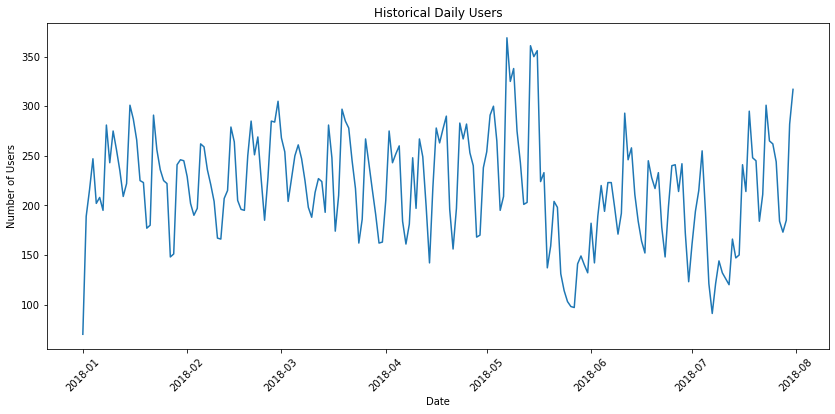

In [22]:
# Plot the graph of the daily users
plt.figure(figsize=(14, 6))
plt.plot(daily_users['Date'], daily_users['Users'])
plt.xticks(rotation=45)
plt.title('Historical Daily Users')
plt.xlabel('Date')
plt.ylabel('Number of Users')
plt.show()

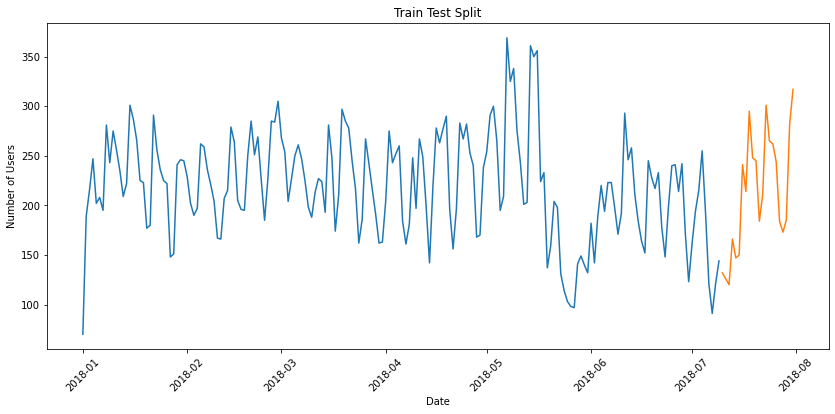

In [23]:
# Split the dataset into train and test
ratio = 0.9
X = daily_users
size = int(len(X) * ratio)
train, test = X[0:size], X[size:len(X)]

plt.figure(figsize=(14, 6))
plt.plot(train['Date'], train['Users'])
plt.plot(test['Date'], test['Users'])
plt.xticks(rotation=45)
plt.title('Train Test Split')
plt.xlabel('Date')
plt.ylabel('Number of Users')
plt.show()

In [24]:
# Fit and evaluate the best ARIMA model
arima_model = auto_arima(train['Users'], seasonal=False, max_p=10)
arima_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  190
Model:               SARIMAX(5, 1, 4)   Log Likelihood                -923.101
Date:                Sun, 18 Jul 2021   AIC                           1866.203
Time:                        18:19:45   BIC                           1898.620
Sample:                             0   HQIC                          1879.336
                                - 190                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2692      0.093      2.900      0.004       0.087       0.451
ar.L2         -0.9871      0.083    -11.834      0.000      -1.151      -0.824
ar.L3          0.0532      0.132      0.403      0.687      -0.205       0.312
ar.L4         -0.6136      0.076     -8.091      0.000      -0.762      -0.465
ar.L5         -0.4642      0.084     -5.549      0.000      -0.628      -0.300
ma.L1         -0.5961      0.074     -8.019      0.000      -0.742      -0.450
ma.L2          1.0192      0.100     10.161      0.000       0.823       1.216
ma.L3         -0.4773      0.093     -5.124      0.000      -0.660      -0.295
ma.L4          0.7726      0.075     10.259      0.000       0.625       0.920
sigma2      1082.4324    118.451      9.138      0.000     850.273    1314.592
===================================================================================
Ljung-Box (L1) (Q):                   0.07   Jarque-Bera (JB):                17.13
Prob(Q):                              0.79   Prob(JB):                         0.00
Heteroskedasticity (H):               1.30   Skew:                             0.58
Prob(H) (two-sided):                  0.30   Kurtosis:                         3.91
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

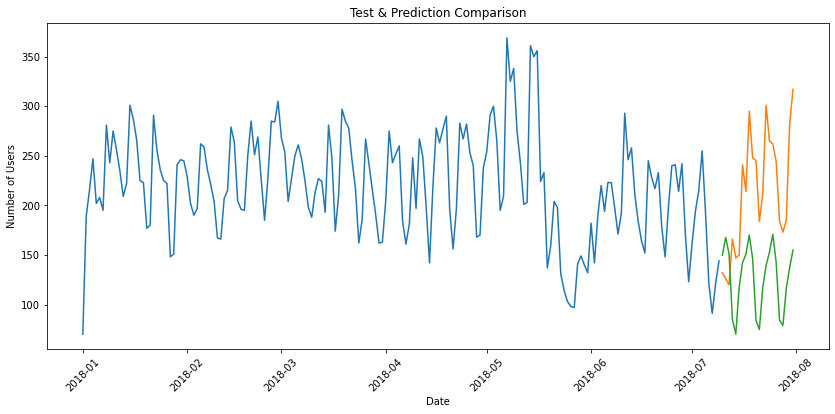

In [25]:
# Predict and compare to the test set
prediction = pd.DataFrame()
prediction['Date'] = test['Date']
prediction['Users'] = arima_model.predict(n_periods=len(test))

plt.figure(figsize=(14, 6))
plt.plot(train['Date'], train['Users'])
plt.plot(test['Date'], test['Users'])
plt.plot(prediction['Date'], prediction['Users'])
plt.xticks(rotation=45)
plt.title('Test & Prediction Comparison')
plt.xlabel('Date')
plt.ylabel('Number of Users')
plt.show()

In [26]:
def get_forecast(data, y, best_params, n_periods):
    p = best_params[0]
    d = best_params[1]
    q = best_params[2]
    arima_model = auto_arima(data[y], seasonal=False, start_p=p, max_p=p, start_d=d, max_d=d, start_q=q, max_q=q)
    predictions = arima_model.predict(n_periods=n_periods)

    result = data.copy()
    result['Forecasted'] = False

    for value in predictions:
        last_row = result.loc[len(result)-1]
        result.loc[len(result)] = [last_row['Date'] + timedelta(days=1), round(value), True]
    
    return result

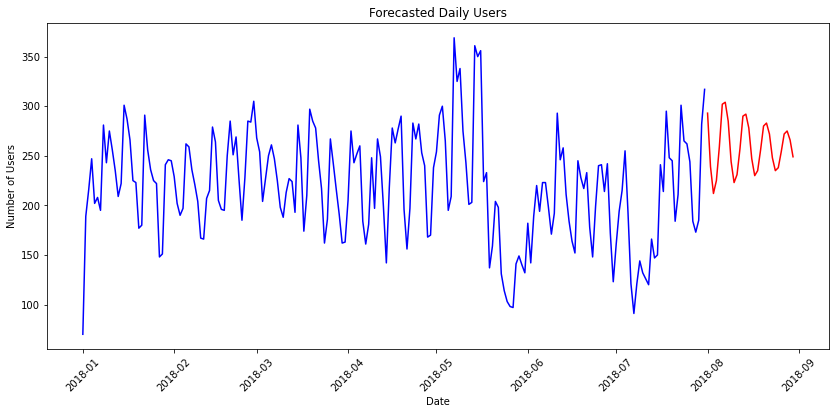

In [27]:
# Forecast future daily users for 30 days
best_params = arima_model.get_params()['order']
users_forecast = get_forecast(daily_users, 'Users', best_params, 30)

# Plot the graph of the forecasted daily users
X1 = users_forecast[users_forecast.Forecasted == False]
X2 = users_forecast[users_forecast.Forecasted == True]

plt.figure(figsize=(14, 6))

plt.plot(X1['Date'], X1['Users'], 'b')
plt.plot(X2['Date'], X2['Users'], 'r')

plt.title('Forecasted Daily Users')
plt.xlabel('Date')
plt.ylabel('Number of Users')
plt.xticks(rotation=45)
plt.show()

## Conclusion

The demonstration shows how ecommerce data can be prepared for analysis and the application of machine learning methods to gain new insights. The charts can be more optimally visualised using data visualisation software such as Tableau and Microsoft BI in addition to data preparation and machine learning techniques via Python.